### Implementing simple chatbot using langgraph

In [2]:
print("test")

test


In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [4]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY")

In [6]:
# Using Open AI
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
llm.invoke("Hi")

AuthenticationError: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [7]:
# Using Groq AI
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="qwen/qwen3-32b")
llm_groq.invoke("Hi I'm Kishore and like to meditate")

AIMessage(content='<think>\nOkay, so the user is Kishore and likes to meditate. Let me start by acknowledging his interest. Meditation is a great practice for mental health and well-being. I should ask him how long he\'s been meditating to get a sense of his experience level. Maybe he\'s a beginner or has been doing it for a while.\n\nI should ask what type of meditation he practices. There are different styles like mindfulness, Vipassana, transcendental meditation, loving-kindness, etc. Knowing which one he uses can help tailor the conversation. Also, I wonder how often he meditates and for how long each session. That gives insight into his routine and consistency.\n\nI should ask about his goals with meditation. Is he trying to reduce stress, improve focus, emotional regulation, or something else? Understanding his motivations can help provide relevant tips or resources. Maybe he faces challenges like difficulty staying focused or finding time. It\'s common for meditators to have suc

### Start with creating nodes

In [9]:
def superbot(state:State):
    res = llm_groq.invoke(state["messages"])
    return {"messages":[res]}

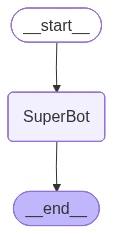

In [10]:
graph = StateGraph(State)

##node 
graph.add_node("SuperBot", superbot)

# Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

compiled_graph = graph.compile()

# Display graph
from IPython.display import Image, display
display(Image(compiled_graph.get_graph().draw_mermaid_png()))


In [11]:
output = compiled_graph.invoke({"messages":"Hi, My name is Kishore and I like table tennis"})

In [12]:
import pprint
pprint.pprint(output)

{'messages': [HumanMessage(content='Hi, My name is Kishore and I like table tennis', additional_kwargs={}, response_metadata={}, id='9efb9c0f-1f16-4c05-8369-2d99c144d456'),
              AIMessage(content="<think>\nOkay, the user just introduced themselves as Kishore and mentioned they like table tennis. I should respond in a friendly and welcoming manner. Let me make sure to acknowledge their name and their interest in table tennis. I can ask them about how they got into the sport or what they enjoy about it to keep the conversation going. Also, maybe offer some tips or information about table tennis if they're interested. Keep the tone positive and engaging.\n</think>\n\nHello, Kishore! 👋 It's great to meet you, and table tennis is an awesome choice—it's such a fun and exciting sport! 🏓 Whether you're into the fast-paced rallies or the strategy behind each serve, there's always something to enjoy.  \n\nHow did you get into table tennis? Are you a casual player or do you compete? If y

## Streaming the responses


In [14]:
for event in compiled_graph.stream({"messages":"Hello My name is Kishore"}, stream_mode="updates"):
    print(event)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced himself as Kishore. I should acknowledge his name and offer assistance. Let me make sure to use his name in the response to personalize it. I'll ask how I can help him today. Keep it friendly and open-ended.\n</think>\n\nHello, Kishore! It's nice to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 15, 'total_tokens': 92, 'completion_time': 0.14761903, 'completion_tokens_details': None, 'prompt_time': 0.000674849, 'prompt_tokens_details': None, 'queue_time': 0.046625591, 'total_time': 0.148293879}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbd83-fdb0-7051-be57-d8c628bf46d2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 77, 'total_t